# Matplotlib Fundamentals

## Overview

Matplotlib is the foundation of Python visualisation. Most other plotting libraries (seaborn, pandas `.plot()`) are built on top of it. Understanding matplotlib's object model is essential for customising any plot.

**The two interfaces:**

| Interface | Style | Use when |
|---|---|---|
| **Pyplot (state-machine)** | `plt.plot()`, `plt.title()` | Quick interactive plots |
| **Object-oriented (OO)** | `fig, ax = plt.subplots()` | Multi-panel figures, full control |

Always use the OO interface for anything beyond a single quick plot. The state-machine interface is unpredictable with multiple figures or subplots.

**Figure anatomy:** `Figure` → `Axes` → `Artists` (lines, patches, text, collections).

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

rng = np.random.default_rng(42)

n = 200
elevation = rng.uniform(50, 400, n)
sites = pd.DataFrame({
    'catchment':  rng.choice(['North', 'South', 'East', 'West'], n),
    'elevation':  elevation.round(1),
    'nitrate':    (rng.gamma(2, 2, n) + 0.008*elevation).round(2),
    'richness':   np.clip((20 - 0.03*elevation + rng.normal(0, 4, n)).round().astype(int), 2, 40),
    'treatment':  rng.choice(['control', 'restored'], n),
})

palette = {'North':'#4a8fff','South':'#4fffb0','East':'#ff6b6b','West':'#ffd166'}

---
## Core Plot Types

C:\Users\saman\AppData\Local\Temp\ipykernel_6424\3250788213.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1,0].boxplot(groups, labels=palette.keys(), patch_artist=True)


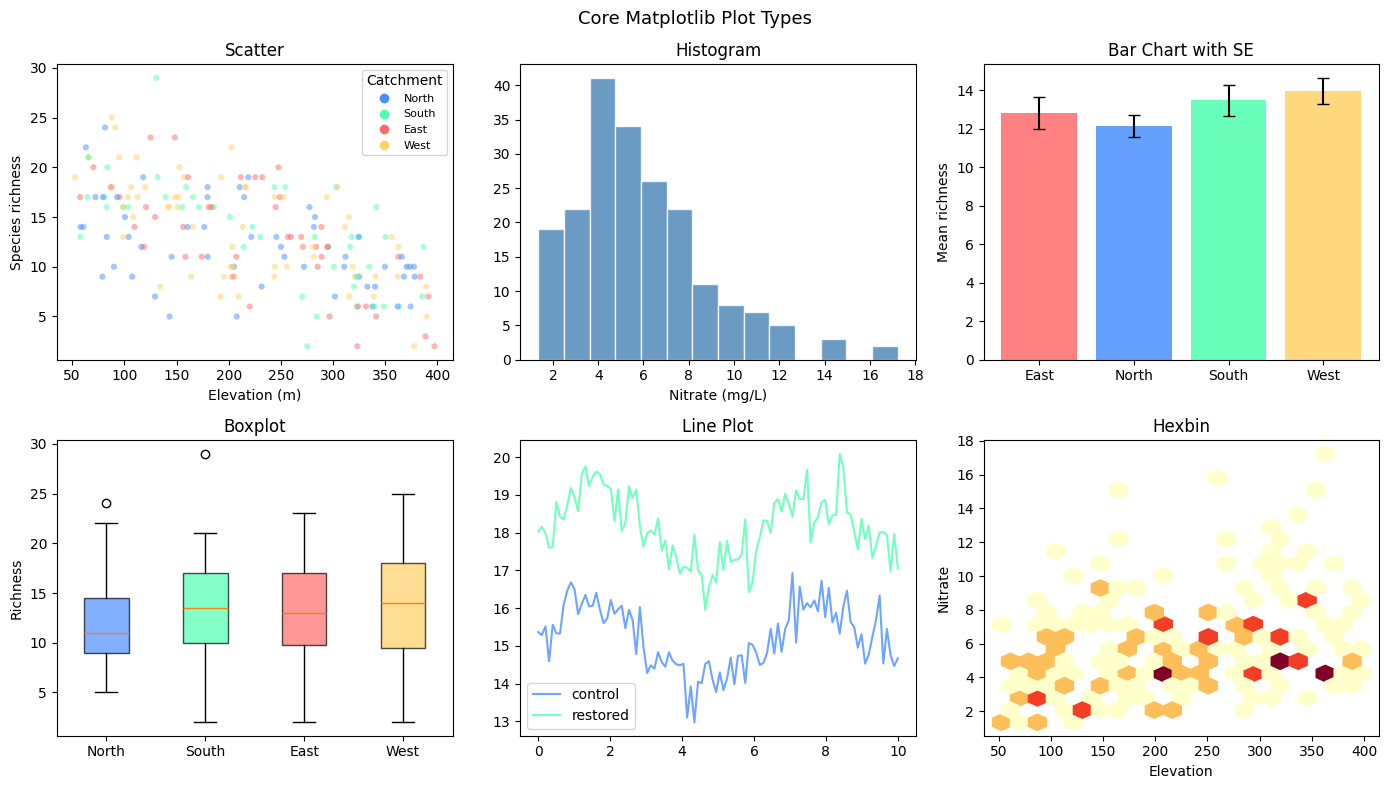

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Scatter
colors = sites['catchment'].map(palette)
axes[0,0].scatter(sites['elevation'], sites['richness'],
                  c=colors, alpha=0.5, s=20, edgecolors='none')
axes[0,0].set_xlabel('Elevation (m)'); axes[0,0].set_ylabel('Species richness')
axes[0,0].set_title('Scatter')
# Custom legend
handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=v, markersize=8, label=k)
           for k, v in palette.items()]
axes[0,0].legend(handles=handles, title='Catchment', fontsize=8)

# Histogram
axes[0,1].hist(sites['nitrate'], bins='fd', color='steelblue',
               edgecolor='white', alpha=0.8)
axes[0,1].set_xlabel('Nitrate (mg/L)'); axes[0,1].set_title('Histogram')

# Bar chart (group means)
means = sites.groupby('catchment')['richness'].mean()
sems  = sites.groupby('catchment')['richness'].sem()
bars  = axes[0,2].bar(means.index, means.values,
                       color=[palette[c] for c in means.index],
                       yerr=sems.values, capsize=4, alpha=0.85)
axes[0,2].set_ylabel('Mean richness'); axes[0,2].set_title('Bar Chart with SE')

# Boxplot
groups = [sites.loc[sites['catchment']==c,'richness'].values for c in palette]
bp = axes[1,0].boxplot(groups, labels=palette.keys(), patch_artist=True)
for patch, color in zip(bp['boxes'], palette.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1,0].set_ylabel('Richness'); axes[1,0].set_title('Boxplot')

# Line plot (time series style)
x = np.linspace(0, 10, 100)
for k, v in [('control','#4a8fff'),('restored','#4fffb0')]:
    noise = rng.normal(0, 0.5, 100)
    y = 15 + (3 if k=='restored' else 0) + np.sin(x) + noise
    axes[1,1].plot(x, y, color=v, alpha=0.8, linewidth=1.5, label=k)
axes[1,1].legend(); axes[1,1].set_title('Line Plot')

# 2D histogram (hex)
axes[1,2].hexbin(sites['elevation'], sites['nitrate'],
                 gridsize=20, cmap='YlOrRd', mincnt=1)
axes[1,2].set_xlabel('Elevation'); axes[1,2].set_ylabel('Nitrate')
axes[1,2].set_title('Hexbin')

plt.suptitle('Core Matplotlib Plot Types', fontsize=13)
plt.tight_layout()
plt.show()

---
## Complex Layouts with GridSpec

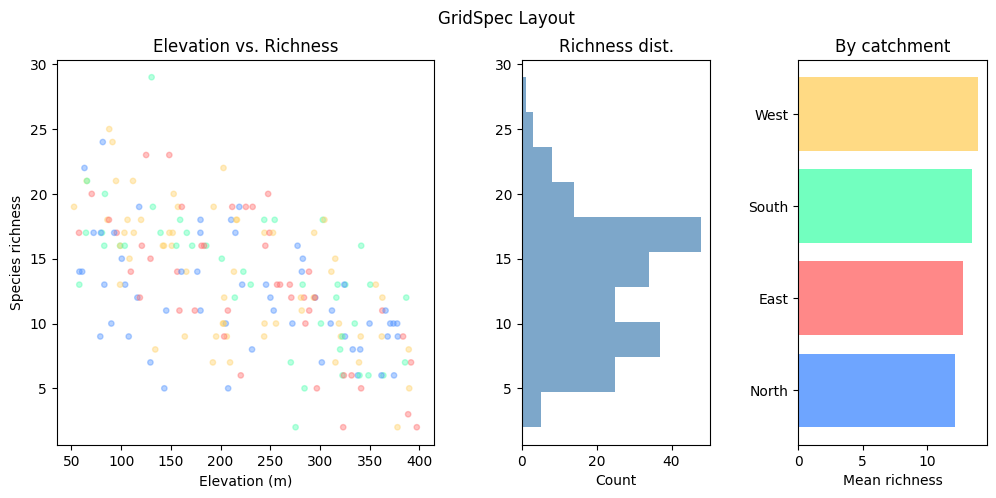

In [3]:
# GridSpec: unequal panel sizes
fig = plt.figure(figsize=(12, 5))
gs  = gridspec.GridSpec(1, 3, width_ratios=[2, 1, 1], wspace=0.35)

ax_main  = fig.add_subplot(gs[0])
ax_right = fig.add_subplot(gs[1])
ax_top   = fig.add_subplot(gs[2])

# Main scatter
ax_main.scatter(sites['elevation'], sites['richness'],
                c=colors, alpha=0.4, s=15)
ax_main.set_xlabel('Elevation (m)'); ax_main.set_ylabel('Species richness')
ax_main.set_title('Elevation vs. Richness')

# Marginal distribution of elevation
ax_right.hist(sites['richness'], bins='fd', orientation='horizontal',
              color='steelblue', alpha=0.7)
ax_right.set_xlabel('Count'); ax_right.set_title('Richness dist.')

# Catchment means
m = sites.groupby('catchment')['richness'].mean().sort_values()
ax_top.barh(m.index, m.values, color=[palette[c] for c in m.index], alpha=0.8)
ax_top.set_xlabel('Mean richness'); ax_top.set_title('By catchment')

plt.suptitle('GridSpec Layout', fontsize=12)
plt.show()

---
## Styling for Publication

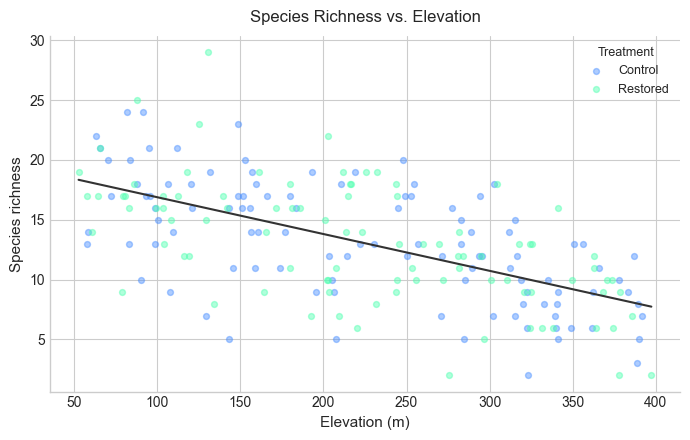

In [4]:
# Publication-quality figure: explicit styling, no chartjunk
with plt.style.context('seaborn-v0_8-whitegrid'):
    fig, ax = plt.subplots(figsize=(7, 4.5))

    for treatment, grp in sites.groupby('treatment'):
        color = '#4a8fff' if treatment == 'control' else '#4fffb0'
        ax.scatter(grp['elevation'], grp['richness'],
                   color=color, alpha=0.45, s=18, label=treatment.title())

    # Regression line with 95% CI band
    from numpy.polynomial import polynomial as P
    x_vals = sites['elevation'].values
    y_vals = sites['richness'].values
    coeffs = np.polyfit(x_vals, y_vals, 1)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 200)
    y_line = np.polyval(coeffs, x_line)
    ax.plot(x_line, y_line, color='#333333', linewidth=1.5, zorder=5)

    ax.set_xlabel('Elevation (m)', fontsize=11)
    ax.set_ylabel('Species richness', fontsize=11)
    ax.set_title('Species Richness vs. Elevation', fontsize=12, pad=10)
    ax.legend(title='Treatment', fontsize=9, title_fontsize=9)
    ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.show()

---

## Common Pitfalls

**1. Using the pyplot state-machine interface for multi-panel figures**  
`plt.subplot()` followed by multiple `plt.plot()` calls is ambiguous when creating more than one figure. The OO interface (`fig, axes = plt.subplots()`) is explicit about which axes each command targets. Use OO for any figure with more than one panel.

**2. Not calling `plt.tight_layout()` or `fig.tight_layout()`**  
Subplot labels and titles frequently overlap without tight layout. Always call `plt.tight_layout()` before `plt.show()`. For `suptitle`, use `plt.tight_layout(rect=[0,0,1,0.96])` to leave room for the super-title.

**3. Saving figures with `plt.savefig()` after `plt.show()`**  
`plt.show()` clears the current figure. Calling `plt.savefig()` after it saves a blank figure. Always save before showing: `fig.savefig('output.png', dpi=300, bbox_inches='tight')` then `plt.show()`.

**4. Using default colour cycles for categorical data without checking accessibility**  
The default matplotlib colour cycle is not colour-blind safe. Use `palette='colorblind'` in seaborn or choose from the Color Universal Design (CUD) palette for any figure intended for publication or public communication.

**5. Hardcoding axis limits before data exploration is complete**  
`ax.set_xlim()` with fixed values breaks when data changes. Set limits relative to data: `ax.set_xlim(data.min()*0.95, data.max()*1.05)` or leave matplotlib to auto-scale and only override when the auto-scale is genuinely misleading.

---
*python_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*